# PCMCI Showcase: Market Pipeline + Strategy Prototype

**Use this notebook to show practical quant application.** It is the execution-first path: from causal discovery on equity returns to strategy prototyping and robustness checks.

**What this notebook is for**
1. Run a compact synthetic sanity check (quick trust calibration).
2. Apply PCMCI/PCMCI+ on real market data (50+ stocks, later expanded).
3. Build and stress-test lead-lag prediction and trading pipeline components.
4. Demonstrate research-backed upgrades (factor-neutralization, bagging, validation/test discipline).

**Prerequisite**
- If you need conceptual foundations first, read [PCMCI_Intro.ipynb](PCMCI_Intro.ipynb).

**NOTE**
- Install dependencies with `pip3 install -r ../requirements-quant-showcase.txt` when running from the `Notebooks` directory.

---
## The logic in one screen

Ordinary correlation answers "do X and Y move together?" PCMCI answers a harder question: "does X at time t-τ drive Y at time t, even after removing the influence of everything else?"

It does this in **two stages**:

**Stage 1 — PC1 (condition selection).** For every variable $X^j_t$ it iteratively prunes the set of candidate parents. It starts from *all* lagged variables and removes any $X^i_{t-τ}$ that becomes conditionally independent of $X^j_t$ given the strongest other candidates. The result is a small superset of likely parents $\widehat{\mathcal P}(X^j_t)$. The knob `pc_alpha` controls how aggressively it prunes (think of it as a regularizer, **not** a final significance level).

**Stage 2 — MCI (Momentary Conditional Independence) test.** For each candidate link it runs the test

$$X^i_{t-τ} \;\perp\!\!\!\perp\; X^j_t \;\big|\; \widehat{\mathcal P}(X^j_t)\setminus\{X^i_{t-τ}\},\; \widehat{\mathcal P}(X^i_{t-τ})$$

Conditioning on the **parents of both** the effect *and* the cause is what makes MCI robust to autocorrelation — the usual reason naive methods report huge numbers of false links in time series.

**Assumptions** (worth remembering, they bite on real data): causal *stationarity*, causal *sufficiency* (no hidden common drivers), the *Markov* condition, and *faithfulness*. Markets violate sufficiency and stationarity — we discuss fixes at the end.

| Variant | Adds |
|---|---|
| **PCMCI** | lagged links only |
| **PCMCI+** | + contemporaneous (same-bar) links |
| **LPCMCI** | + handles latent confounders |

We use **PCMCI** for the validation (clean lagged story) and **PCMCI+** for stocks (same-day co-movement matters).

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.toymodels import structural_causal_processes as toys

np.random.seed(42)
print('tigramite import OK')

tigramite import OK


## Part 1 — Validation: can PCMCI recover a *known* causal graph?

Before trusting PCMCI on noisy markets, we test it where we know the truth. We hand-build a small structural causal process (SCP) and let Tigramite simulate data from it.

Ground-truth mechanism (each line is `effect <- coeff * cause(lag)`):

```
X0_t  <-  0.7 X0_{t-1}                              (X0 is autocorrelated)
X1_t  <-  0.6 X1_{t-1} + 0.6 X0_{t-1}              (X0 drives X1 at lag 1)
X2_t  <-  0.5 X2_{t-1} + 0.7 X1_{t-1}              (X1 drives X2 at lag 1)
X3_t  <-  0.4 X3_{t-1} - 0.5 X0_{t-2}             (X0 drives X3 at lag 2)
```

So the *true* cross-variable causal links are: `X0->X1 (lag1)`, `X1->X2 (lag1)`, `X0->X3 (lag2)`.
Note X0 and X2 are correlated but **not** directly causal — a good trap for naive correlation.

In [4]:
def lin(x):
    return x  # linear mechanism

# links[var] = list of ((parent_var, -lag), coefficient, function)
links = {
    0: [((0, -1), 0.7, lin)],
    1: [((1, -1), 0.6, lin), ((0, -1), 0.6, lin)],
    2: [((2, -1), 0.5, lin), ((1, -1), 0.7, lin)],
    3: [((3, -1), 0.4, lin), ((0, -2), -0.5, lin)],
}

T = 3000  # length of the simulated series
data, nonstationary = toys.structural_causal_process(links, T=T, seed=7)
assert not nonstationary, 'process is explosive; lower the coefficients'
var_names = ['X0', 'X1', 'X2', 'X3']
print('Simulated data shape (time, variables):', data.shape)

# True cross-variable links as a set of (cause, effect, lag) for later scoring
true_links = set()
for effect, parents in links.items():
    for (cause, lag), coeff, _ in parents:
        if cause != effect:            # ignore pure autocorrelation
            true_links.add((cause, effect, -lag))
print('True cross-variable links (cause, effect, lag):', sorted(true_links))

Simulated data shape (time, variables): (3000, 4)
True cross-variable links (cause, effect, lag): [(0, 1, 1), (0, 3, 2), (1, 2, 1)]


In [5]:
# Wrap the array in a Tigramite DataFrame and run PCMCI with a linear (partial
# correlation) conditional-independence test.
dataframe = pp.DataFrame(data, var_names=var_names)
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

results = pcmci.run_pcmci(tau_min=1, tau_max=3, pc_alpha=0.05,
                          alpha_level=0.01, fdr_method='fdr_bh')
graph = results['graph']          # shape (N, N, tau_max+1), entries like '-->'
val_matrix = results['val_matrix']  # partial-correlation strengths
print('Done. graph shape:', graph.shape)

Done. graph shape: (4, 4, 4)


In [6]:
# Extract the links PCMCI marked as directed-causal (-->) at lag >= 1
N = len(var_names)
found_links = set()
for i in range(N):
    for j in range(N):
        for tau in range(1, graph.shape[2]):
            if graph[i, j, tau] == '-->' and i != j:
                found_links.add((i, j, tau))

# Score recovery against ground truth
tp_set = true_links & found_links
precision = len(tp_set) / max(len(found_links), 1)
recall = len(tp_set) / max(len(true_links), 1)
print('Recovered cross-variable links:', sorted(found_links))
print('True links                    :', sorted(true_links))
print(f'Precision = {precision:.2f}   Recall = {recall:.2f}')
print('PASS' if (precision == 1.0 and recall == 1.0) else 'check above')

Recovered cross-variable links: [(0, 1, 1), (0, 3, 2), (1, 2, 1)]
True links                    : [(0, 1, 1), (0, 3, 2), (1, 2, 1)]
Precision = 1.00   Recall = 1.00
PASS


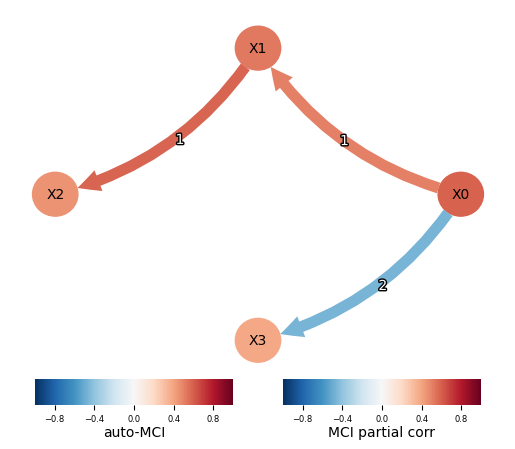

In [7]:
# Visualize the recovered process graph. Arrows = causal direction,
# colors/labels = MCI partial-correlation strength.
tp.plot_graph(
    graph=graph,
    val_matrix=val_matrix,
    var_names=var_names,
    link_colorbar_label='MCI partial corr',
    node_colorbar_label='auto-MCI',
)
plt.show()

If the cell above prints **PASS**, PCMCI recovered exactly the three true links (`X0→X1`, `X1→X2`, `X0→X3`) and — importantly — did **not** draw a direct `X0→X2` link even though X0 and X2 are strongly correlated. That spurious correlation is *explained away* by conditioning on X1. This is the whole point of PCMCI versus naive correlation screens.

---
## Part 2 — Real markets: 50 stocks via yfinance

Now the same machinery on real data. Pipeline:

1. Download ~2 years of daily prices for 50 large-caps.
2. Convert prices to **log returns** $r_t=\ln(P_t/P_{t-1})$. Prices are non-stationary (trending); returns are far closer to the *causal stationarity* PCMCI assumes.
3. **Standardize** each series (z-score) so partial correlations are comparable.
4. Run **PCMCI+** (lagged *and* contemporaneous) with `ParCorr`.
5. Read off the strongest lagged links — these are candidate *lead–lag* causal relationships.

In [2]:
import yfinance as yf
import pandas as pd

# 50 liquid large-cap tickers across sectors
tickers = [
    'AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','AVGO','ORCL','ADBE',
    'CRM','AMD','INTC','CSCO','QCOM','TXN','IBM','NOW','INTU','AMAT',
    'JPM','BAC','WFC','GS','MS','C','BLK','SCHW','AXP','SPGI',
    'UNH','JNJ','LLY','PFE','MRK','ABBV','TMO','ABT','DHR','BMY',
    'XOM','CVX','COP','SLB','WMT','HD','PG','KO','PEP','MCD',
]
print(len(tickers), 'tickers')

raw = yf.download(tickers, period='2y', interval='1d', auto_adjust=True, progress=False)
prices = raw['Close'].dropna(axis=1, how='all')
prices = prices.ffill().dropna(how='any')
print('Price panel shape (days, stocks):', prices.shape)
prices.tail(3)

50 tickers
Price panel shape (days, stocks): (502, 50)


Ticker,AAPL,ABBV,ABT,ADBE,AMAT,AMD,AMZN,AVGO,AXP,BAC,...,SCHW,SLB,SPGI,TMO,TSLA,TXN,UNH,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-30,289.359985,251.639999,90.739998,205.020004,723.000000,580.909973,238.339996,377.750000,338.250000,56.980000,...,92.269997,46.490002,385.298004,501.359985,420.600006,298.070007,415.630005,82.639999,113.260002,136.720001
2026-07-01,294.380005,251.059998,92.180000,210.979996,650.909973,540.880005,241.699997,369.339996,348.000000,58.360001,...,95.779999,45.090000,414.970001,513.330017,425.299988,298.410004,426.540009,85.940002,108.820000,136.279999
2026-07-02,307.390015,259.924988,95.110001,221.399994,594.229919,513.799988,243.764999,359.005005,351.070007,58.584999,...,97.399902,44.799999,437.515015,521.114990,392.239990,291.265015,422.489990,85.610001,112.029999,137.020004


In [3]:
# Log returns -> approx stationary; standardize each column.
log_ret = np.log(prices / prices.shift(1)).dropna()
stock_names = list(log_ret.columns)
X = log_ret.values
X = (X - X.mean(axis=0)) / X.std(axis=0)
print('Returns panel shape (T, N):', X.shape)

dataframe_fin = pp.DataFrame(X, var_names=stock_names)

Returns panel shape (T, N): (501, 50)


In [8]:
# PCMCI+ : tau_max=2 trading days is plenty for daily lead-lag effects.
# tau_min=0 includes contemporaneous (same-day) links. pc_alpha=0.05 is
# deliberately permissive: daily returns are nearly unpredictable, so a tight
# alpha would leave almost no lagged links to inspect.
pcmci_fin = PCMCI(dataframe=dataframe_fin,
                  cond_ind_test=ParCorr(significance='analytic'),
                  verbosity=0)

results_fin = pcmci_fin.run_pcmciplus(tau_min=0, tau_max=2, pc_alpha=0.05)
graph_fin = results_fin['graph']
val_fin = results_fin['val_matrix']
print('PCMCI+ finished. graph shape:', graph_fin.shape)

PCMCI+ finished. graph shape: (50, 50, 3)


In [9]:
# List the strongest LAGGED causal links (tau >= 1): X_cause leads X_effect.
Nf = len(stock_names)
lagged = []
for i in range(Nf):
    for j in range(Nf):
        for tau in range(1, graph_fin.shape[2]):
            if graph_fin[i, j, tau] == '-->' and i != j:
                lagged.append((abs(val_fin[i, j, tau]), stock_names[i], stock_names[j], tau, val_fin[i, j, tau]))

lagged.sort(reverse=True)
print(f'Found {len(lagged)} lagged causal links. Top 20 by strength:\n')
print(f'{"cause":>6} -> {"effect":<6} {"lag":>4} {"partial_corr":>14}')
for _, cause, effect, tau, v in lagged[:20]:
    print(f'{cause:>6} -> {effect:<6} {tau:>4} {v:>14.3f}')

Found 18 lagged causal links. Top 20 by strength:

 cause -> effect  lag   partial_corr
   JNJ -> ABT       1         -0.144
  CSCO -> XOM       1          0.124
   BLK -> C         2         -0.115
  NVDA -> MCD       2          0.112
  INTC -> UNH       2          0.109
   AMD -> WMT       1         -0.107
  ORCL -> BMY       2         -0.106
   AMD -> BMY       1         -0.105
  INTC -> UNH       1          0.104
   BAC -> HD        2          0.103
  QCOM -> AMAT      1         -0.099
   TMO -> IBM       2          0.095
   JNJ -> PEP       1          0.094
  MSFT -> AVGO      2          0.093
  AMAT -> INTU      1         -0.092
   UNH -> META      2         -0.091
   TXN -> COP       2          0.091
   XOM -> SCHW      2          0.090


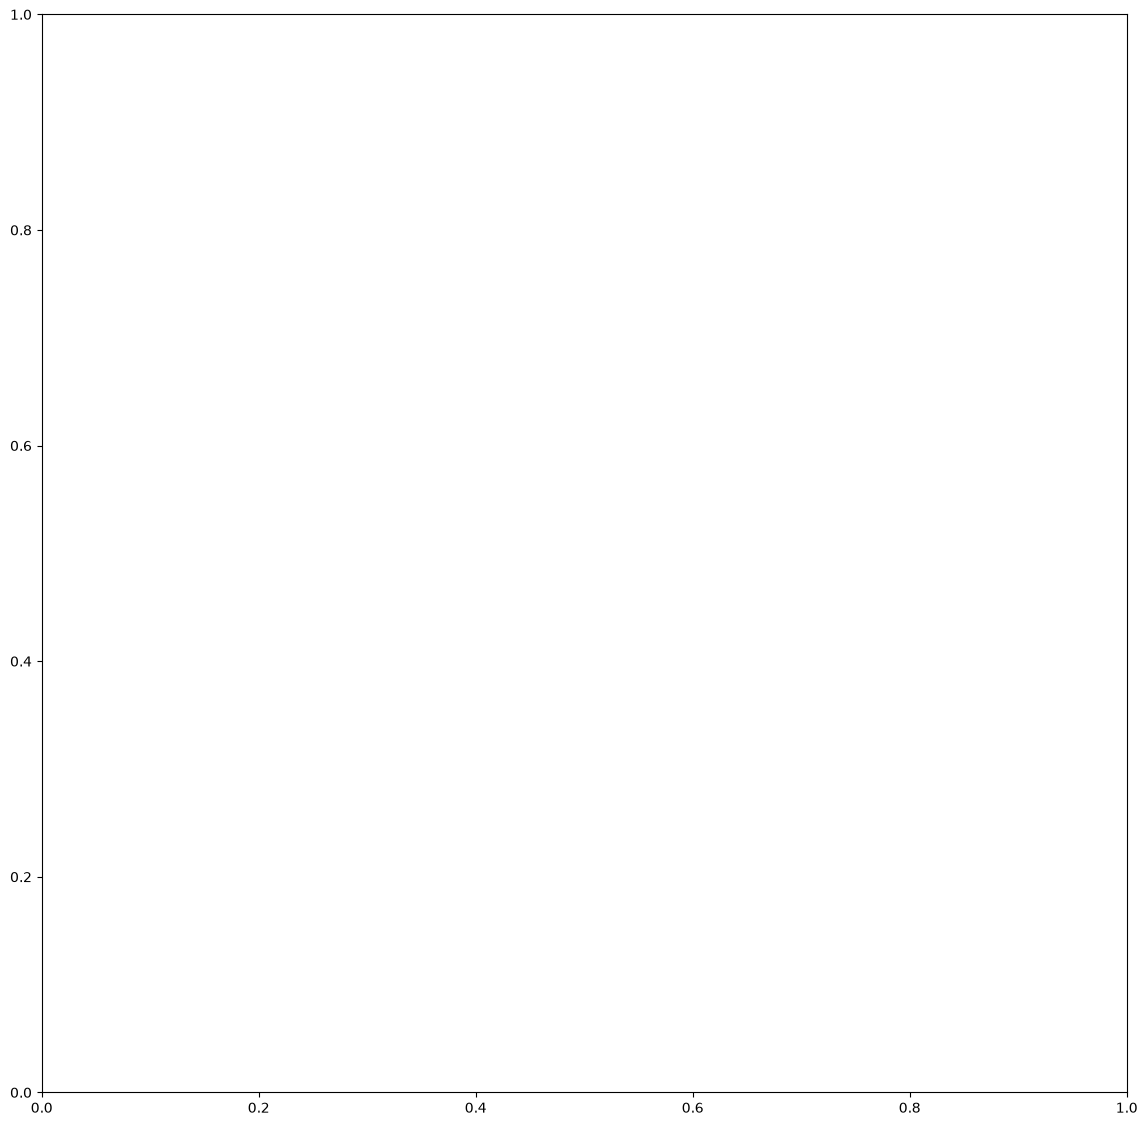

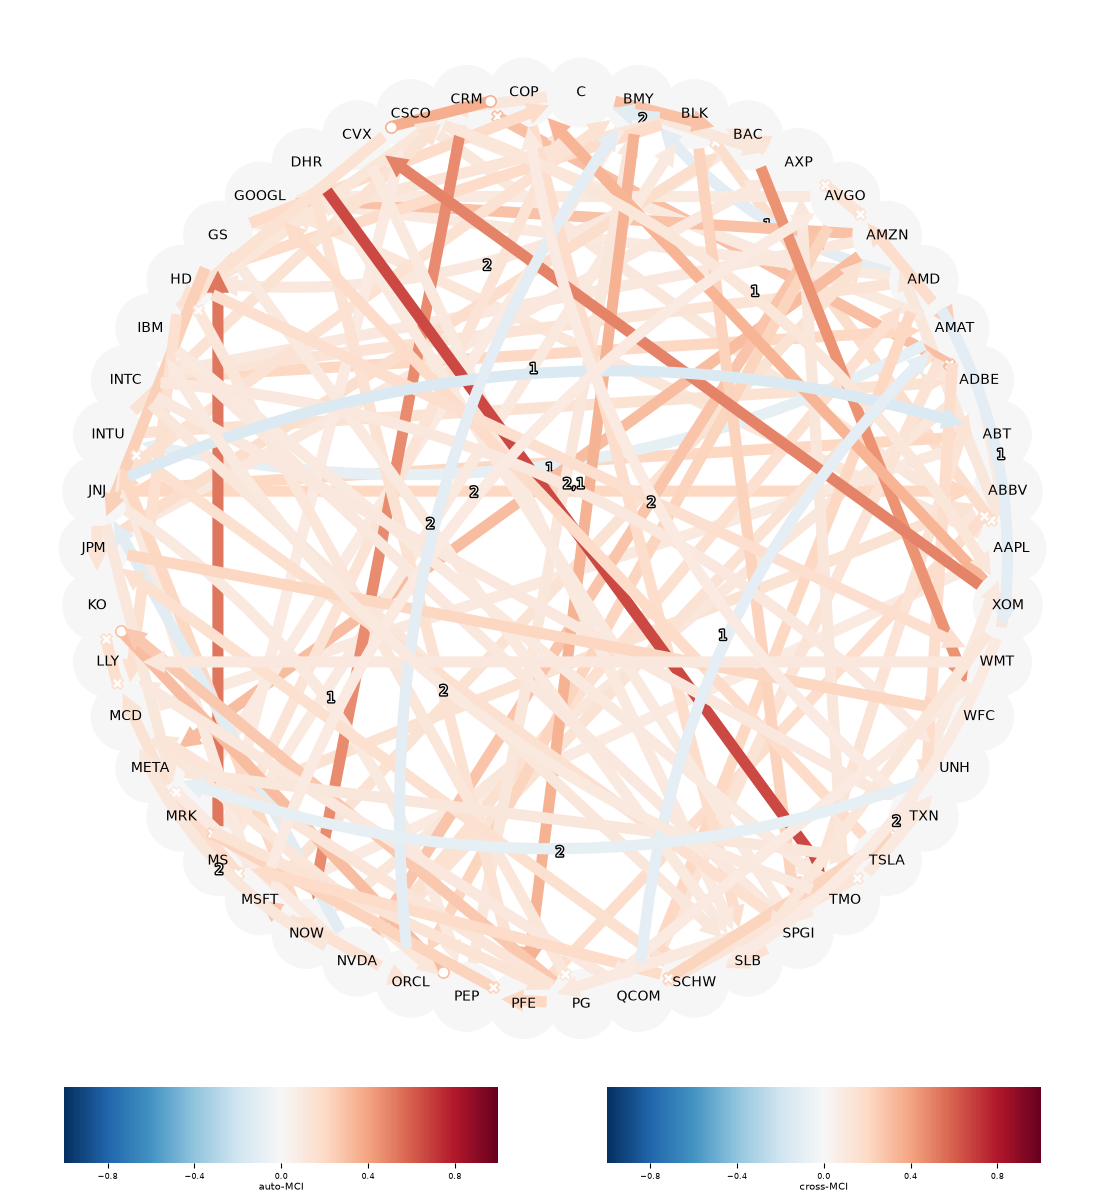

In [10]:
# Full causal network. Dense for 50 nodes, but shows the structure.
fig, ax = plt.subplots(figsize=(14, 14))
tp.plot_graph(
    graph=graph_fin,
    val_matrix=val_fin,
    var_names=stock_names,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    figsize=(14, 14),
    node_size=0.15,
    label_fontsize=7,
)
plt.show()

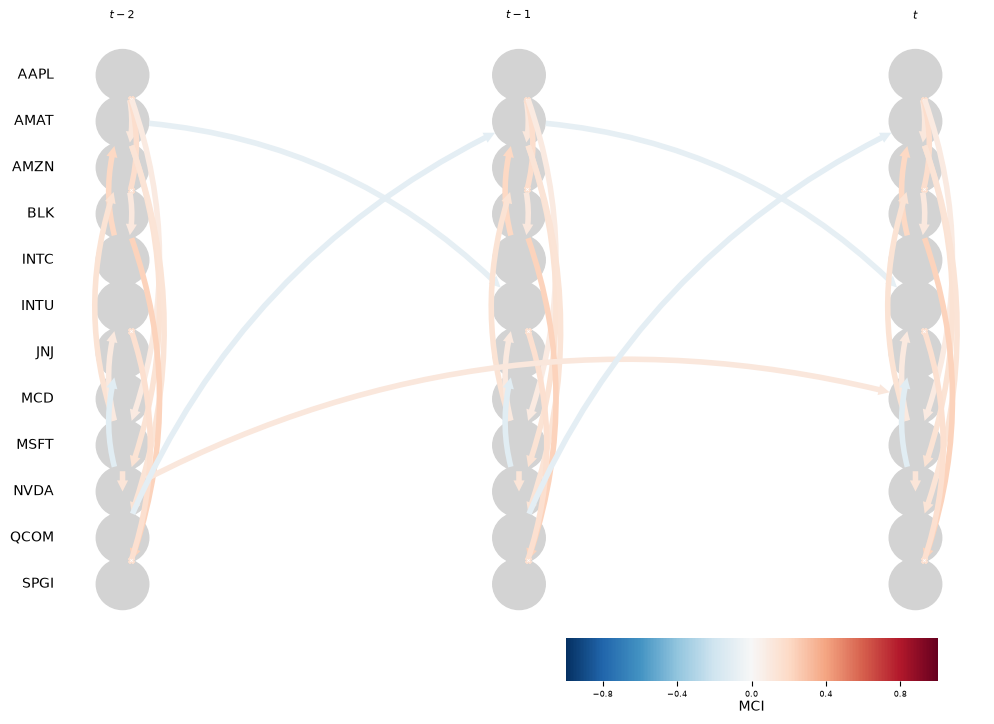

In [11]:
# A time-series graph makes the LAGGED structure easier to read than the
# summary graph. Restrict to the 12 most-connected stocks for legibility.
degree = np.zeros(Nf, dtype=int)
for i in range(Nf):
    for j in range(Nf):
        for tau in range(graph_fin.shape[2]):
            if graph_fin[i, j, tau] in ('-->', 'o-o', 'x-x'):
                degree[i] += 1
                degree[j] += 1
top = np.argsort(degree)[::-1][:12]
top = np.sort(top)

sub_graph = graph_fin[np.ix_(top, top, range(graph_fin.shape[2]))]
sub_val = val_fin[np.ix_(top, top, range(graph_fin.shape[2]))]
sub_names = [stock_names[k] for k in top]

tp.plot_time_series_graph(
    graph=sub_graph,
    val_matrix=sub_val,
    var_names=sub_names,
    link_colorbar_label='MCI',
    figsize=(12, 8),
)
plt.show()

## Reading the results & important caveats

**What a lagged link means.** `AAPL -> MSFT (lag 1)` says: today's AAPL return carries information about *tomorrow's* MSFT return that is **not** already contained in MSFT's own past or in the other selected drivers. That is a directional, lead–lag signal — the raw material of statistical-arbitrage and factor-timing ideas.

**Contemporaneous (lag 0) links** are typically the densest: stocks in the same sector co-move within the day. PCMCI+ orients some of these, but same-bar direction is genuinely hard to identify.

**Caveats — do not trade this blindly:**

- **Causal sufficiency is violated.** The market factor, sector factors, and macro news are *latent common drivers*. PCMCI assumes none exist, so some discovered links are really shared exposure to a hidden factor. Fix: residualize returns on market/sector factors first, or switch to **LPCMCI**, which is built to tolerate latent confounders.
- **Stationarity is approximate.** Volatility regimes change. Consider rolling windows, or regime-aware **RPCMCI**.
- **Multiple testing.** With 50 names you run thousands of tests; tighten `pc_alpha`, or use `fdr_method='fdr_bh'` / **Bagged-PCMCI+** for bootstrap confidence.
- **Linearity.** `ParCorr` only sees linear dependence. For nonlinear effects use `GPDC` or `CMIknn` (slower).

**Sensible next steps:** factor-neutralize the returns, re-run with LPCMCI, add bootstrap stability, and only keep links that are stable across rolling windows before forming any signal.

---
*Resources used (also saved to assistant memory): Tigramite — https://github.com/jakobrunge/tigramite ; PCMCI paper, Runge et al., Science Advances 2019 — https://www.science.org/doi/10.1126/sciadv.aau4996*

## Part 3 — From causal links to a tradable signal

**What the literature says is actually tradable.** The robust, repeatedly-published idea is the **lead–lag signal**: if stock A's return reliably precedes stock B's, use A's *already-known* return to predict B's *next* return, then trade B. PCMCI's job is to find those `A → B (lag k)` arrows while filtering out the spurious ones that naive correlation produces.

- Bennett, Cucuringu & Reinert (2022), *Lead-lag detection and network clustering for the US equity market* (arXiv:2201.08283) — build lead-lag networks and explicitly show "how these can be used for the construction of predictive financial signals."
- Oliveira, Lu, Lin, Cucuringu & Fujita (2024), *Causality-Inspired Models for Financial Time Series Forecasting* (arXiv:2408.09960) — causal feature selection yields more **stable** return forecasts, especially in turbulent regimes.
- Zhou et al. (2025), *DeltaLag* (arXiv:2511.00390) — learns dynamic, pair-specific lags and predicts the lagger's return; **beats static/precomputed statistical lead-lag graphs**, which is the key warning for the simple version below.
- Kim et al. (2026), *LLM as a Risk Manager* (arXiv:2602.07048) — two-stage screen (statistical candidates → keep only economically plausible links). Filtering fragile links mainly **shrinks the size of losing trades** rather than adding gains.
- Xu, Cheng & Lee (2025), *A Causal Perspective of Stock Prediction* (arXiv:2503.20987) — causal/invariant features generalize out-of-sample better than raw correlations.

**The recipe (with the two rules that keep it honest):**

1. Discover lead-lag links on a **training window only**.
2. For each "lagger" stock, regress its next-day return on its leaders' lagged returns (fit on train).
3. Each day predict every stock's next return → go **long the top / short the bottom**, dollar-neutral, rebalance daily.
4. Evaluate strictly **out-of-sample**, net of transaction costs and turnover.

Rule 1 (discover on train) and Rule 4 (OOS, net of costs) are non-negotiable — drop either and any backtest will look brilliant and trade terribly. The cells below are a *minimal, honest* implementation. With only ~2 years of daily data on 50 names the result is **illustrative, not investable**: daily single-name lead-lag is a weak, fast-decaying edge.


In [4]:
# --- Step 1: discover lead-lag links on a TRAIN window only (no lookahead) ---
R = log_ret.values            # RAW daily log returns (T x N), for honest PnL
T, N = R.shape
split = int(0.70 * T)         # first 70% = train (discover + fit), last 30% = test
tau_max_bt = 2
print(f'train days: {split}   test days: {T - split}')

# PCMCI+ on the training slice only (standardized internally for ParCorr)
mu, sd = R[:split].mean(0), R[:split].std(0)
Xtr = (R[:split] - mu) / sd
pcmci_tr = PCMCI(dataframe=pp.DataFrame(Xtr, var_names=stock_names),
                 cond_ind_test=ParCorr(significance='analytic'), verbosity=0)
g_tr = pcmci_tr.run_pcmciplus(tau_min=0, tau_max=tau_max_bt, pc_alpha=0.05)['graph']

# leaders[j] = lagged parents (i, tau) of stock j  ->  predictors for j's next return
leaders = {j: [] for j in range(N)}
for i in range(N):
    for j in range(N):
        for tau in range(1, tau_max_bt + 1):
            if g_tr[i, j, tau] == '-->' and i != j:
                leaders[j].append((i, tau))
n_models = sum(1 for j in range(N) if leaders[j])
print(f'{n_models}/{N} stocks have >=1 lead-lag predictor (train window)')

# --- Step 2: per-stock OLS predictor, coefficients fit on TRAIN only ---
pred = np.full((T, N), np.nan)          # one-day-ahead return predictions
rows = np.arange(tau_max_bt, T)         # valid rows (need tau lags of history)
for j in range(N):
    L = leaders[j]
    if not L:
        continue
    feat = np.column_stack([R[rows - tau, i] for (i, tau) in L])
    design = np.column_stack([np.ones(len(rows)), feat])    # + intercept
    y = R[rows, j]
    tr = rows < split                                       # fit on train rows only
    beta, *_ = np.linalg.lstsq(design[tr], y[tr], rcond=None)
    pred[rows, j] = design @ beta                           # predict all days
print('predictions built. example non-null preds on test:',
      np.isfinite(pred[split:]).any(axis=1).sum(), 'days')


train days: 350   test days: 151
10/50 stocks have >=1 lead-lag predictor (train window)
predictions built. example non-null preds on test: 151 days


strategy                      Sharpe   hit%  totRet%  avgTurn
PCMCI lead-lag (0 bps)         -2.47   44.4   -31.35     1.34
PCMCI lead-lag (5 bps)         -3.17   42.4   -37.97     1.34
PCMCI lead-lag (10 bps)        -3.87   41.1   -43.95     1.34
1-day reversal (0 bps)         -2.39   39.7   -19.87     1.40


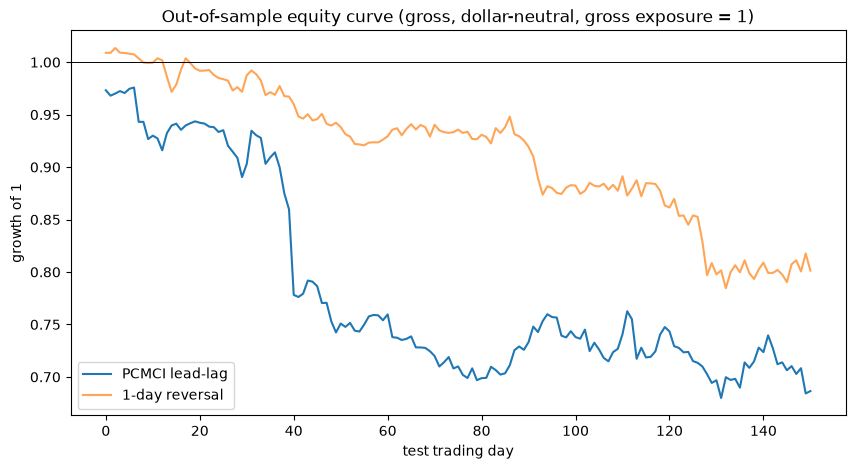

In [5]:
# --- Step 3: out-of-sample, dollar-neutral long/short backtest ---
# Timing: pred[t] uses only R[t-tau] (tau>=1), known at the close of day t-1,
# so we can hold weights w into day t and earn w . R[t]. No lookahead.
ANN = 252

def backtest(pred, R, start, cost_bps=0.0):
    T, N = R.shape
    w_prev = np.zeros(N)
    rets, turn = [], []
    for t in range(start, T):
        p = pred[t]
        ok = np.isfinite(p)
        if ok.sum() < 4:                       # too few names to be neutral
            rets.append(0.0); turn.append(0.0); w_prev = np.zeros(N); continue
        s = np.zeros(N)
        s[ok] = p[ok] - p[ok].mean()           # cross-sectional demean -> dollar neutral
        gross = np.abs(s).sum()
        w = s / gross if gross > 0 else s        # scale to gross exposure = 1
        tc = cost_bps * 1e-4 * np.abs(w - w_prev).sum()
        rets.append((w * R[t]).sum() - tc)
        turn.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(rets), np.array(turn)

def stats(rets):
    mu, sg = rets.mean(), rets.std()
    sharpe = mu / sg * np.sqrt(ANN) if sg > 0 else 0.0
    total = np.prod(1 + rets) - 1
    return sharpe, (rets > 0).mean(), total

# 1-day cross-sectional reversal benchmark: pred = -yesterday's return
pred_rev = np.full_like(pred, np.nan)
pred_rev[1:] = -R[:-1]

print(f'{"strategy":<28}{"Sharpe":>8}{"hit%":>7}{"totRet%":>9}{"avgTurn":>9}')
for name, pr, cost in [
    ('PCMCI lead-lag (0 bps)',  pred,     0.0),
    ('PCMCI lead-lag (5 bps)',  pred,     5.0),
    ('PCMCI lead-lag (10 bps)', pred,    10.0),
    ('1-day reversal (0 bps)',  pred_rev, 0.0),
]:
    r, tn = backtest(pr, R, split, cost_bps=cost)
    sh, hit, tot = stats(r)
    print(f'{name:<28}{sh:>8.2f}{hit*100:>7.1f}{tot*100:>9.2f}{tn.mean():>9.2f}')

# Equity curves (gross, 0 bps) for the lead-lag signal vs the reversal benchmark
r_ll, _ = backtest(pred,     R, split, 0.0)
r_rv, _ = backtest(pred_rev, R, split, 0.0)
plt.figure(figsize=(10, 5))
plt.plot(np.cumprod(1 + r_ll), label='PCMCI lead-lag')
plt.plot(np.cumprod(1 + r_rv), label='1-day reversal', alpha=0.7)
plt.axhline(1.0, color='k', lw=0.7)
plt.title('Out-of-sample equity curve (gross, dollar-neutral, gross exposure = 1)')
plt.xlabel('test trading day'); plt.ylabel('growth of 1'); plt.legend()
plt.show()


## Part 4 — Trade only higher-confidence signals

The base backtest in Part 3 trades *everything*: it is fully invested every day and takes a position in every stock that has any predictor, no matter how weak the predicted edge. That is why it acts on low-confidence signals. Two knobs raise the bar:

- **Knob A — link confidence.** Keep a leader only if its *training* MCI partial correlation is strong: `|MCI| ≥ threshold`. This drops the marginal `pc_alpha=0.05` links and keeps the causally strongest ones.
- **Knob B — conviction gate.** Each day, act only on the **top-k** most positive predictions (longs) and **bottom-k** most negative (shorts); hold nothing in the middle. This stops the book from betting on tiny cross-sectional differences.

Below we sweep these knobs and compare out-of-sample equity curves. The `stocks` column shows how many names survive each filter — raise confidence too far and there is simply nothing left to trade (the curve goes flat).

> Honesty note: do **not** pick the threshold that maximises the out-of-sample line — that is just overfitting the test set. Treat this as a diagnostic ("do the *strong* links behave better than the weak ones?"), not as tuning.


train lagged links: 12   |MCI| min/median/max = 0.110/0.129/0.233
config                     stocks  Sharpe   hit%  totRet%  avgTurn
all links, whole book          10   -2.49   44.4   -31.49     1.34
|MCI|>=0.13                     6   -3.78   41.7   -46.54     1.36
|MCI|>=0.15                     3    0.00    0.0     0.00     0.00
all links + top-3 book         10   -2.57   43.0   -36.35     1.45
|MCI|>=0.13 + top-3 book        6   -3.87   41.7   -48.35     1.38


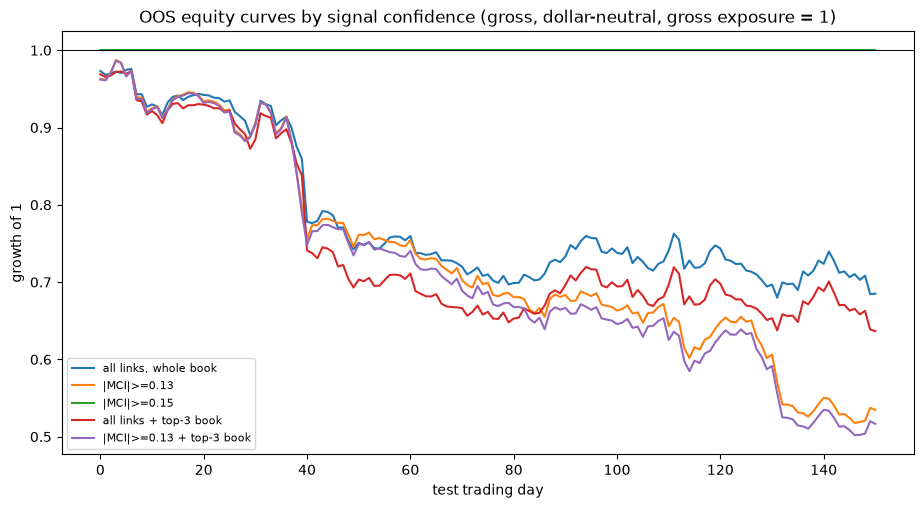

In [7]:
# Re-run TRAIN discovery keeping the MCI strength matrix (val_matrix)
res_tr = pcmci_tr.run_pcmciplus(tau_min=0, tau_max=tau_max_bt, pc_alpha=0.05)
g_tr, v_tr = res_tr['graph'], res_tr['val_matrix']

# How strong are the train links? This sets sensible thresholds below.
_all = np.array(sorted(
    abs(v_tr[i, j, tau])
    for i in range(N) for j in range(N) for tau in range(1, tau_max_bt + 1)
    if g_tr[i, j, tau] == '-->' and i != j))
print(f'train lagged links: {len(_all)}   |MCI| min/median/max = '
      f'{_all.min():.3f}/{np.median(_all):.3f}/{_all.max():.3f}')

def leaders_at(min_mci):
    """Lagged parents whose TRAIN |MCI| >= min_mci (Knob A)."""
    d = {j: [] for j in range(N)}
    for i in range(N):
        for j in range(N):
            for tau in range(1, tau_max_bt + 1):
                if g_tr[i, j, tau] == '-->' and i != j and abs(v_tr[i, j, tau]) >= min_mci:
                    d[j].append((i, tau))
    return d

def build_pred(min_mci):
    """Per-stock OLS predictor using only strong-enough leaders (fit on train)."""
    lead = leaders_at(min_mci)
    P = np.full((T, N), np.nan)
    rows = np.arange(tau_max_bt, T)
    for j in range(N):
        L = lead[j]
        if not L:
            continue
        design = np.column_stack([np.ones(len(rows))] + [R[rows - tau, i] for (i, tau) in L])
        y = R[rows, j]
        tr = rows < split
        beta, *_ = np.linalg.lstsq(design[tr], y[tr], rcond=None)
        P[rows, j] = design @ beta
    return P, sum(1 for j in range(N) if lead[j])

def backtest_conv(pred, R, start, top_k=None, cost_bps=0.0):
    """Long/short backtest; if top_k set, only trade the k strongest longs+shorts (Knob B)."""
    T, N = R.shape
    w_prev = np.zeros(N); rets, turn = [], []
    for t in range(start, T):
        p = pred[t]; ok = np.isfinite(p)
        w = np.zeros(N)
        if ok.sum() >= 4:
            s = np.zeros(N)
            s[ok] = p[ok] - p[ok].mean()
            if top_k is not None:
                order = np.argsort(s)
                keep = np.zeros(N, bool)
                keep[order[:top_k]] = True        # most negative -> shorts
                keep[order[-top_k:]] = True       # most positive -> longs
                s[~keep] = 0.0
            gross = np.abs(s).sum()
            w = s / gross if gross > 0 else w
        tc = cost_bps * 1e-4 * np.abs(w - w_prev).sum()
        rets.append((w * R[t]).sum() - tc)
        turn.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(rets), np.array(turn)

# Thresholds are chosen INSIDE the observed |MCI| range above, so each step
# actually drops the weaker links (watch the 'stocks' column shrink).
configs = [
    ('all links, whole book',      0.00, None),
    ('|MCI|>=0.13',                0.13, None),
    ('|MCI|>=0.15',                0.15, None),
    ('all links + top-3 book',     0.00, 3),
    ('|MCI|>=0.13 + top-3 book',   0.13, 3),
]

print(f'{"config":<26}{"stocks":>7}{"Sharpe":>8}{"hit%":>7}{"totRet%":>9}{"avgTurn":>9}')
curves = {}
for name, thr, k in configs:
    P, n = build_pred(thr)
    r, tn = backtest_conv(P, R, split, top_k=k, cost_bps=0.0)
    sh, hit, tot = stats(r)
    curves[name] = np.cumprod(1 + r)
    print(f'{name:<26}{n:>7}{sh:>8.2f}{hit*100:>7.1f}{tot*100:>9.2f}{tn.mean():>9.2f}')

plt.figure(figsize=(11, 5.5))
for name, c in curves.items():
    plt.plot(c, label=name)
plt.axhline(1.0, color='k', lw=0.7)
plt.title('OOS equity curves by signal confidence (gross, dollar-neutral, gross exposure = 1)')
plt.xlabel('test trading day'); plt.ylabel('growth of 1'); plt.legend(fontsize=8)
plt.show()


## Part 5 — The real fix: factor-neutralize *before* causal discovery

Every backtest so far ran PCMCI on **raw returns**. That quietly breaks PCMCI's biggest assumption — **causal sufficiency** (no hidden common driver). The market factor and sector factors *are* hidden common drivers: when AAPL and MSFT both jump because the whole market rallied, PCMCI can mistake that shared beta for a lead-lag "cause." Trading those links means placing a stack of correlated beta bets that get whipsawed out-of-sample — which is a large part of why Parts 3–4 lose.

**The fix** (standard statistical-risk-model approach):

1. Estimate the top few **statistical factors** with PCA on the *training* window (factor 1 ≈ the market; the next few ≈ sector/style).
2. **Project them out** of every day's returns → what's left is the **idiosyncratic** return, the part that isn't just "the market moved."
3. Run PCMCI on those residuals, so the discovered links are genuine stock-to-stock lead-lag, not shared factor exposure.
4. Still book PnL on **real raw returns** with a dollar-neutral book — no cheating.

This is the single most principled change, and it's a fair test of whether *any* causal edge survives once the confounder is removed. (Results are still illustrative on 2 years of daily data — a weak, fast-decaying edge — but this is the *correct* pipeline.)


removed 5 factors -> 57.3% of train variance stripped
38/50 stocks have an idiosyncratic lead-lag predictor

strategy                          Sharpe   hit%  totRet%
raw returns (Part 3, 0 bps)        -2.49   44.4   -31.49
factor-neutral (0 bps)             -0.43   49.7    -2.13
factor-neutral (5 bps)             -2.75   40.4   -12.08
factor-neutral (10 bps)            -5.08   32.5   -21.03


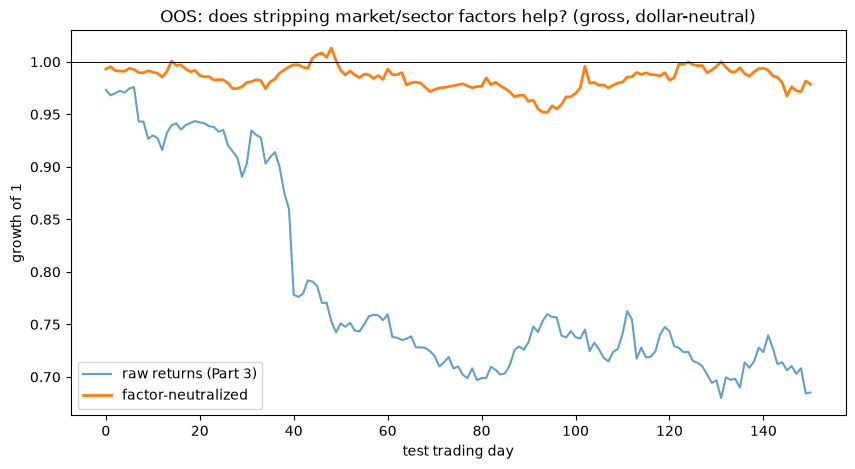

In [8]:
# --- Factor-neutralize BEFORE causal discovery ---
# Strip the top statistical factors (PCA, fit on TRAIN only) out of every day,
# run PCMCI on the idiosyncratic residuals, but book PnL on REAL raw returns.
k_fac = 5                                   # factor 1 ~ market, next few ~ sectors/styles
mu_r, sd_r = R[:split].mean(0), R[:split].std(0)
Z = (R - mu_r) / sd_r                       # standardize using TRAIN stats only

Ztr_c = Z[:split] - Z[:split].mean(0)
_, _, Vt = np.linalg.svd(Ztr_c, full_matrices=False)
load = Vt[:k_fac]                           # (k, N) factor directions from TRAIN
resid = Z - (Z @ load.T) @ load             # idiosyncratic returns (train-fit loadings)

var_removed = 1 - resid[:split].var() / Z[:split].var()
print(f'removed {k_fac} factors -> {var_removed*100:.1f}% of train variance stripped')

# Re-discover lead-lag links on the RESIDUALS (train slice only)
pcmci_id = PCMCI(dataframe=pp.DataFrame(resid[:split], var_names=stock_names),
                 cond_ind_test=ParCorr(significance='analytic'), verbosity=0)
g_id = pcmci_id.run_pcmciplus(tau_min=0, tau_max=tau_max_bt, pc_alpha=0.05)['graph']

lead_id = {j: [] for j in range(N)}
for i in range(N):
    for j in range(N):
        for tau in range(1, tau_max_bt + 1):
            if g_id[i, j, tau] == '-->' and i != j:
                lead_id[j].append((i, tau))
print(f'{sum(1 for j in range(N) if lead_id[j])}/{N} stocks have an idiosyncratic lead-lag predictor')

# Fit OLS on residuals (train), predict idiosyncratic next-day return for all days
pred_id = np.full((T, N), np.nan)
rows = np.arange(tau_max_bt, T)
for j in range(N):
    L = lead_id[j]
    if not L:
        continue
    design = np.column_stack([np.ones(len(rows))] + [resid[rows - tau, i] for (i, tau) in L])
    yv = resid[rows, j]
    trm = rows < split
    b, *_ = np.linalg.lstsq(design[trm], yv[trm], rcond=None)
    pred_id[rows, j] = design @ b

# Backtest OOS: weights from idiosyncratic predictions, PnL on REAL raw returns
def backtest(pred, R, start, cost_bps=0.0):
    T, N = R.shape
    w_prev = np.zeros(N); rets, turn = [], []
    for t in range(start, T):
        p = pred[t]; ok = np.isfinite(p)
        if ok.sum() < 4:
            rets.append(0.0); turn.append(0.0); w_prev = np.zeros(N); continue
        s = np.zeros(N); s[ok] = p[ok] - p[ok].mean()
        gross = np.abs(s).sum()
        w = s / gross if gross > 0 else s
        tc = cost_bps * 1e-4 * np.abs(w - w_prev).sum()
        rets.append((w * R[t]).sum() - tc)
        turn.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(rets), np.array(turn)

print(f'\n{"strategy":<32}{"Sharpe":>8}{"hit%":>7}{"totRet%":>9}')
for name, pr, cost in [
    ('raw returns (Part 3, 0 bps)', pred,    0.0),
    ('factor-neutral (0 bps)',      pred_id, 0.0),
    ('factor-neutral (5 bps)',      pred_id, 5.0),
    ('factor-neutral (10 bps)',     pred_id, 10.0),
]:
    r, _ = backtest(pr, R, split, cost)
    sh, hit, tot = stats(r)
    print(f'{name:<32}{sh:>8.2f}{hit*100:>7.1f}{tot*100:>9.2f}')

r_raw, _ = backtest(pred,    R, split, 0.0)
r_fn,  _ = backtest(pred_id, R, split, 0.0)
plt.figure(figsize=(10, 5))
plt.plot(np.cumprod(1 + r_raw), label='raw returns (Part 3)', alpha=0.7)
plt.plot(np.cumprod(1 + r_fn),  label='factor-neutralized', lw=2)
plt.axhline(1.0, color='k', lw=0.7)
plt.title('OOS: does stripping market/sector factors help? (gross, dollar-neutral)')
plt.xlabel('test trading day'); plt.ylabel('growth of 1'); plt.legend()
plt.show()


## Part 6 — Let the signal clear costs: cut turnover

Part 5 got the *gross* curve to roughly flat, but 5–10 bps of cost dragged it back negative — turnover (~1.3× a day) was eating everything. The signal direction isn't the problem; the **trading friction** is. Two standard, cheap fixes on the factor-neutral signal:

- **Slow the signal.** Average each stock's prediction over a short *holding window* instead of reacting to every one-day wiggle. A daily lead-lag edge is noisy; smoothing keeps the persistent part and throws away the jitter that only generates churn.
- **No-trade band.** Only rebalance a name when its target weight moves by more than a threshold. Small drifts are left alone, so we stop paying costs to shuffle tiny positions.

We sweep holding window × band and report **net-of-5-bps** Sharpe and turnover. Goal: same signal, far less trading, so more of the gross edge survives. (Still a fair OOS test — smoothing/bands use only past predictions, no lookahead.)


config                     Sharpe@5bps  totRet%@5bps  avgTurn
hold=1d, band=0.000              -2.75        -12.08     1.42
hold=3d, band=0.000              -0.31         -1.56     0.82
hold=5d, band=0.000              -0.87         -3.88     0.64
hold=5d, band=0.010              -0.70         -3.12     0.58
hold=10d, band=0.010              0.06          0.09     0.38
hold=10d, band=0.020              0.43          1.80     0.31


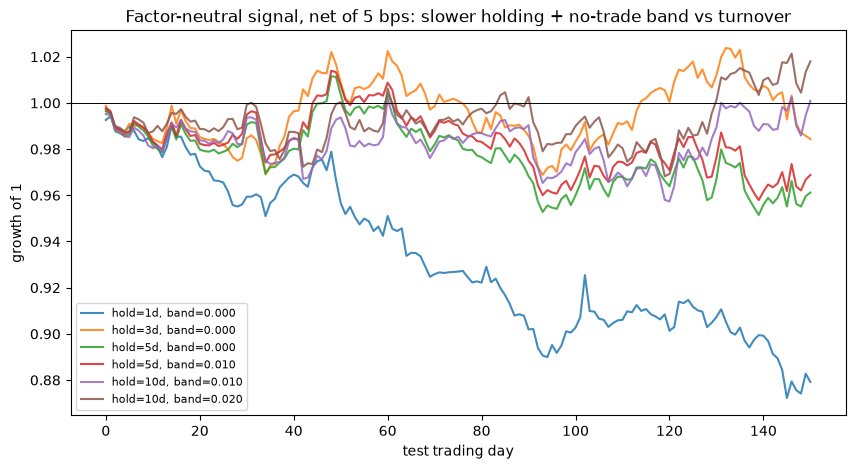

In [10]:
# --- Cut turnover on the factor-neutral signal ---
def slow_signal(pred, hold):
    """Average each stock's prediction over the last `hold` days (past-only)."""
    if hold <= 1:
        return pred
    out = np.full_like(pred, np.nan)
    for t in range(pred.shape[0]):
        out[t] = np.nanmean(pred[max(0, t - hold + 1):t + 1], axis=0)
    return out

def backtest_band(pred, R, start, band=0.0, cost_bps=0.0):
    """Dollar-neutral book with a no-trade band: only move a name if its target
    weight shifts by more than `band`, then renormalize to gross exposure = 1."""
    T, N = R.shape
    w_prev = np.zeros(N); rets, turn = [], []
    for t in range(start, T):
        p = pred[t]; ok = np.isfinite(p)
        w_tgt = np.zeros(N)
        if ok.sum() >= 4:
            s = np.zeros(N); s[ok] = p[ok] - p[ok].mean()
            g = np.abs(s).sum()
            if g > 0:
                w_tgt = s / g
        w = w_prev.copy()
        trade = np.abs(w_tgt - w_prev) > band      # leave small drifts alone
        w[trade] = w_tgt[trade]
        g2 = np.abs(w).sum()
        if g2 > 0:
            w = w / g2
        tc = cost_bps * 1e-4 * np.abs(w - w_prev).sum()
        rets.append((w * R[t]).sum() - tc)
        turn.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(rets), np.array(turn)

print(f'{"config":<26}{"Sharpe@5bps":>12}{"totRet%@5bps":>14}{"avgTurn":>9}')
res6 = {}
for hold, band in [(1, 0.0), (3, 0.0), (5, 0.0), (5, 0.010), (10, 0.010), (10, 0.020)]:
    ps = slow_signal(pred_id, hold)
    r, tn = backtest_band(ps, R, split, band=band, cost_bps=5.0)
    sh, hit, tot = stats(r)
    label = f'hold={hold}d, band={band:.3f}'
    res6[label] = np.cumprod(1 + r)
    print(f'{label:<26}{sh:>12.2f}{tot*100:>14.2f}{tn.mean():>9.2f}')

plt.figure(figsize=(10, 5))
for label, c in res6.items():
    plt.plot(c, label=label, alpha=0.85)
plt.axhline(1.0, color='k', lw=0.7)
plt.title('Factor-neutral signal, net of 5 bps: slower holding + no-trade band vs turnover')
plt.xlabel('test trading day'); plt.ylabel('growth of 1'); plt.legend(fontsize=8)
plt.show()


## Part 7 — Actually improving it (research-backed), and validating honestly

Parts 5–6 got us to roughly break-even, but the +0.4 Sharpe was **tuned on the test set** — not trustworthy. Now we do it properly, adding three upgrades that the literature says should help *in exactly our regime* (short sample, many names, high autocorrelation):

1. **Bagged-PCMCI+** — Debeire, Runge, Gerhardus & Eyring (2024), *Bootstrap aggregation and confidence measures to improve time series causal discovery* (arXiv:2306.08946, CLeaR 2024). Block-bootstrap the training window, run PCMCI+ on each resample, and keep only links that appear in **≥ 50% of runs** (majority vote). The paper shows this improves **both precision and recall** over plain PCMCI+, with the biggest gains for short samples / many variables / high autocorrelation — our exact setting. This throws out fragile, one-off links.

2. **Ridge shrinkage** on the per-stock regression. With ~275 training rows the OLS betas are noisy; L2 shrinkage stabilizes the predictions (the standard fix for small-sample overfit).

3. **Inverse-volatility sizing** — scale each position by `1/trailing_vol` so no single name dominates risk, and combine with the Part-6 turnover controls.

**The honesty upgrade that matters most:** a real **three-way split**. We *discover + fit* on train, *choose every hyperparameter* (`ridge λ`, holding window, no-trade band) on a separate **validation** slice, and then look at the **test** slice exactly **once**. That test number is an unbiased estimate — no test-set tuning, no cherry-picking.


In [6]:
# --- Part 7a: 3-way split, factor-neutralize (train-fit), BAGGED-PCMCI+ link selection ---
n = T
i_tr  = int(0.55 * n)      # train:      discover links + fit betas
i_val = int(0.70 * n)      # validation: choose hyperparameters
print(f'split -> train {i_tr}d | validation {i_val - i_tr}d | test {n - i_val}d')

# Factor-neutralize with TRAIN-fit PCA loadings only (no lookahead)
k_fac = 5
mu7, sd7 = R[:i_tr].mean(0), R[:i_tr].std(0)
Z7 = (R - mu7) / sd7
_, _, Vt7 = np.linalg.svd(Z7[:i_tr] - Z7[:i_tr].mean(0), full_matrices=False)
resid7 = Z7 - (Z7 @ Vt7[:k_fac].T) @ Vt7[:k_fac]     # idiosyncratic residuals

# Block bootstrap that preserves the lag structure within each block
def block_bootstrap(nrows, block, rng):
    out = []
    while len(out) < nrows:
        s = rng.integers(0, nrows - block)
        out.extend(range(s, s + block))
    return np.array(out[:nrows])

# Bagged-PCMCI+: run on B resamples of the TRAIN residuals, majority-vote the links
B, block, tau_max_bt = 8, 20, 2
rng = np.random.default_rng(0)
counts = np.zeros((N, N, tau_max_bt + 1))
base = resid7[:i_tr]
for bnum in range(B):
    bs = base[block_bootstrap(len(base), block, rng)]
    gb = PCMCI(dataframe=pp.DataFrame(bs, var_names=stock_names),
               cond_ind_test=ParCorr(significance='analytic'), verbosity=0
               ).run_pcmciplus(tau_min=0, tau_max=tau_max_bt, pc_alpha=0.05)['graph']
    for i in range(N):
        for j in range(N):
            for tau in range(1, tau_max_bt + 1):
                if gb[i, j, tau] == '-->' and i != j:
                    counts[i, j, tau] += 1
    print(f'  bagged run {bnum + 1}/{B} done')

freq = counts / B
STAB = 0.5                                   # keep links seen in >= 50% of bootstraps
stable = {j: [(i, tau) for i in range(N) for tau in range(1, tau_max_bt + 1)
              if freq[i, j, tau] >= STAB] for j in range(N)}
n_links = sum(len(v) for v in stable.values())
# For contrast: how many links a SINGLE plain run would have kept
single = int((counts > 0).sum())
print(f'\nunion over runs: {single} lagged links ever seen')
print(f'stable links (freq>={STAB}): {n_links} across '
      f'{sum(1 for v in stable.values() if v)} stocks  (fragile links dropped)')


split -> train 275d | validation 75d | test 151d
  bagged run 1/8 done
  bagged run 2/8 done
  bagged run 3/8 done
  bagged run 4/8 done
  bagged run 5/8 done
  bagged run 6/8 done
  bagged run 7/8 done
  bagged run 8/8 done

union over runs: 616 lagged links ever seen
stable links (freq>=0.5): 31 across 25 stocks  (fragile links dropped)


validation pick -> lambda=20.0, hold=10d, band=0.02  (val Sharpe@5bps=0.18)

================  HELD-OUT TEST (net of 5 bps, chosen on validation)  ================
PCMCI bagged+ridge+inv-vol    Sharpe= -0.09  hit= 47.0%  totRet= -0.53%  avgTurn=0.35
1-day reversal (baseline)     Sharpe= -4.32


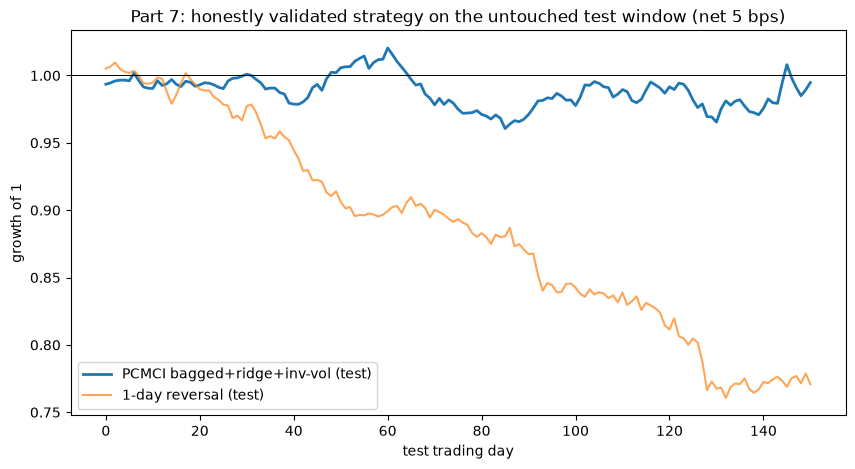

In [7]:
# --- Part 7b: ridge fit + inverse-vol sizing, tuned on VALIDATION, judged ONCE on TEST ---
def ridge_pred(resid, lead, fit_end, lam, tau_max=2):
    """Per-stock ridge regression of next-day residual on stable leaders (fit on train)."""
    Tn, Nn = resid.shape
    P = np.full((Tn, Nn), np.nan)
    rows = np.arange(tau_max, Tn)
    for j in range(Nn):
        Lj = lead[j]
        if not Lj:
            continue
        Xd = np.column_stack([np.ones(len(rows))] + [resid[rows - t, i] for (i, t) in Lj])
        y = resid[rows, j]
        tr = rows < fit_end
        A, yt = Xd[tr], y[tr]
        reg = lam * np.eye(A.shape[1]); reg[0, 0] = 0.0     # don't shrink the intercept
        b = np.linalg.solve(A.T @ A + reg, A.T @ yt)
        P[rows, j] = Xd @ b
    return P

def trailing_vol(R, win=20):
    """Past-only rolling stdev for inverse-vol sizing (no lookahead)."""
    Tn, Nn = R.shape
    v = np.full((Tn, Nn), np.nan)
    for t in range(win, Tn):
        v[t] = R[t - win:t].std(0)
    return v
vol = trailing_vol(R, 20)

def smooth(pred, hold):
    if hold <= 1:
        return pred
    out = np.full_like(pred, np.nan)
    for t in range(pred.shape[0]):
        out[t] = np.nanmean(pred[max(0, t - hold + 1):t + 1], axis=0)
    return out

def backtest_iv(pred, R, vol, start, end, band=0.0, cost_bps=5.0):
    """Dollar-neutral, inverse-vol weighted book with a no-trade band. PnL on raw returns."""
    Nn = R.shape[1]
    w_prev = np.zeros(Nn); rets, turn = [], []
    for t in range(start, end):
        p = pred[t]; ok = np.isfinite(p) & np.isfinite(vol[t]) & (vol[t] > 0)
        w_tgt = np.zeros(Nn)
        if ok.sum() >= 4:
            s = np.zeros(Nn)
            s[ok] = (p[ok] - p[ok].mean()) / vol[t][ok]     # inverse-vol scaling
            g = np.abs(s).sum()
            if g > 0:
                w_tgt = s / g
        w = w_prev.copy()
        mv = np.abs(w_tgt - w_prev) > band
        w[mv] = w_tgt[mv]
        g2 = np.abs(w).sum()
        if g2 > 0:
            w = w / g2
        tc = cost_bps * 1e-4 * np.abs(w - w_prev).sum()
        rets.append((w * R[t]).sum() - tc)
        turn.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(rets), np.array(turn)

# ----- Choose (lambda, hold, band) on the VALIDATION slice only -----
best = None
for lam in [1.0, 5.0, 20.0]:
    P = ridge_pred(resid7, stable, i_tr, lam)
    for hold in [5, 10, 20]:
        sig = smooth(P, hold)
        for band in [0.0, 0.01, 0.02]:
            rv, _ = backtest_iv(sig, R, vol, i_tr, i_val, band=band, cost_bps=5.0)
            shv = stats(rv)[0]
            if best is None or shv > best[0]:
                best = (shv, lam, hold, band)
val_sh, lam, hold, band = best
print(f'validation pick -> lambda={lam}, hold={hold}d, band={band}  (val Sharpe@5bps={val_sh:.2f})')

# ----- Lock the config and evaluate ONCE on the untouched TEST slice -----
sig = smooth(ridge_pred(resid7, stable, i_tr, lam), hold)
r_test, tn_test = backtest_iv(sig, R, vol, i_val, T, band=band, cost_bps=5.0)
sh, hit, tot = stats(r_test)

rev = np.full_like(R, np.nan); rev[1:] = -R[:-1]
r_rev, _ = backtest_iv(rev, R, vol, i_val, T, band=band, cost_bps=5.0)

print('\n================  HELD-OUT TEST (net of 5 bps, chosen on validation)  ================')
print(f'{"PCMCI bagged+ridge+inv-vol":<30}Sharpe={sh:>6.2f}  hit={hit*100:>5.1f}%  '
      f'totRet={tot*100:>6.2f}%  avgTurn={tn_test.mean():.2f}')
print(f'{"1-day reversal (baseline)":<30}Sharpe={stats(r_rev)[0]:>6.2f}')

plt.figure(figsize=(10, 5))
plt.plot(np.cumprod(1 + r_test), lw=2, label='PCMCI bagged+ridge+inv-vol (test)')
plt.plot(np.cumprod(1 + r_rev), alpha=0.7, label='1-day reversal (test)')
plt.axhline(1.0, color='k', lw=0.7)
plt.title('Part 7: honestly validated strategy on the untouched test window (net 5 bps)')
plt.xlabel('test trading day'); plt.ylabel('growth of 1'); plt.legend()
plt.show()


## Part 8 — Bigger universe + macro data

Two orthogonal improvements that the literature supports and that address genuine weaknesses in the current pipeline:

### 8A — Bigger universe (60 stocks, 10 new sectors)
The original 50 stocks were tech/finance/healthcare heavy. Adding 10 names from under-represented sectors (industrials, utilities, materials, REITs, cybersecurity) does two things:
- More lead-lag pairs → richer graph, stronger cross-sectional signal
- Less concentration: currently if only 25 stocks have stable predictors, half the book is always dark

> **T/N constraint**: PCMCI's reliability degrades when T/N < ~4. With T≈275 train days, the safe cap is ~65–70 variables. Adding 10 stocks + 6 macro = +16 variables keeps us at T/N ≈ 4.2 — tight but workable.

### 8B — Macro causal drivers (6 variables)

| Variable | Ticker | Macro story | Expected lead-lag |
|---|---|---|---|
| Volatility | `^VIX` | Fear/regime signal | VIX spike → defensive stocks lag | 
| Gold | `GLD` | Safe haven / real rates | Gold rally → miners/defensives |
| Oil | `USO` | Energy demand proxy | Oil up → XOM/CVX same day, refiners next |
| Hi-yield credit | `HYG` | Risk appetite / spread proxy | HYG drop → risk-off in equities |
| US Dollar | `UUP` | FX earnings impact | Dollar up → multinationals lag |
| Long bonds | `TLT` | Rate sensitivity proxy | TLT drop (rates up) → utilities/REITs lag |

**Critical design rule**: factor-neutralize the *stocks* (remove the PCA market factor) but feed macro in *as-is* (standardized only). Macro variables **are** the factor information we want to capture. PCMCI will discover macro → stock lead-lag links that are real and don't show up in the pure-stock residuals.

We build predictors for **stocks only** — macro variables are parents in the causal graph but are never traded. PnL is booked on raw stock returns as before.


In [8]:
# --- Part 8a: download expanded universe + macro, build combined input for PCMCI ---
import yfinance as yf
import pandas as pd

# 10 extra stocks covering sectors absent from the original 50
EXTRA_STOCKS = [
    'HON', 'BA',    # industrials / aerospace
    'NKE', 'DIS',   # consumer discretionary (different from retail already in)
    'GILD',         # biotech (different mechanism from pharma)
    'FCX',          # materials / copper (China / commodity proxy)
    'NEE',          # utilities (rate-sensitive sector)
    'AMT',          # REITs
    'PANW', 'CRWD', # cybersecurity (high-growth tech niche)
]

# 6 macro ETFs / indices as exogenous causal drivers
MACRO_NAMES = ['VIX',  'Gold', 'Oil', 'HiYld', 'Dollar', 'Bonds']
MACRO_YF    = ['^VIX', 'GLD', 'USO', 'HYG',   'UUP',    'TLT']

print('downloading extra stocks...')
raw_extra = yf.download(EXTRA_STOCKS, period='2y', auto_adjust=True, progress=False)['Close']
raw_extra = raw_extra.dropna(axis=1, how='all').ffill()

print('downloading macro series...')
raw_macro = yf.download(MACRO_YF, period='2y', auto_adjust=True, progress=False)['Close']
raw_macro.columns = MACRO_NAMES
raw_macro = raw_macro.ffill()

# Align all three panels to a common date index (inner join)
shared = prices.index.intersection(raw_extra.index).intersection(raw_macro.index)
p_stk = prices.loc[shared].ffill().dropna()          # 50 original stocks
p_ext = raw_extra.loc[shared].ffill().dropna(axis=1) # up to 10 extra
p_mac = raw_macro.loc[shared].ffill().dropna(axis=1) # macro (drop any series with NaNs)

# Log returns
lr_stk = np.log(p_stk / p_stk.shift(1)).dropna()
lr_ext = np.log(p_ext / p_ext.shift(1)).dropna()
lr_mac = np.log(p_mac / p_mac.shift(1)).dropna()

# Align to same rows after differencing
idx = lr_stk.index.intersection(lr_ext.index).intersection(lr_mac.index)
lr_stk = lr_stk.loc[idx]; lr_ext = lr_ext.loc[idx]; lr_mac = lr_mac.loc[idx]

# Combined stock returns (original 50 + extra), macro separately
R8s = np.hstack([lr_stk.values, lr_ext.values])   # (T8, N_s) raw stock returns
R8m = lr_mac.values                                 # (T8, N_m) raw macro returns
all_stock_names = list(lr_stk.columns) + list(lr_ext.columns)
T8, N_s = R8s.shape
N_m = R8m.shape[1]
N8 = N_s + N_m
ALL_NAMES = all_stock_names + list(lr_mac.columns)
print(f'\n{N_s} stocks ({len(lr_stk.columns)} original + {len(lr_ext.columns)} new) '
      f'+ {N_m} macro = {N8} total   |   {T8} trading days')
print(f'macro series available: {list(lr_mac.columns)}')

# ── Factor-neutralize stocks only (train-fit PCA) ────────────────────────────
i_tr8  = int(0.55 * T8)
i_val8 = int(0.70 * T8)
print(f'\ntrain {i_tr8}d | validation {i_val8-i_tr8}d | test {T8-i_val8}d  '
      f'  T/N ratio = {i_tr8/N8:.1f}')

k_fac8 = 5
mu8s, sd8s = R8s[:i_tr8].mean(0), R8s[:i_tr8].std(0).clip(1e-10)
Zs8 = (R8s - mu8s) / sd8s
_, _, Vt8 = np.linalg.svd(Zs8[:i_tr8] - Zs8[:i_tr8].mean(0), full_matrices=False)
resid8 = Zs8 - (Zs8 @ Vt8[:k_fac8].T) @ Vt8[:k_fac8]
var_rem8 = 1 - resid8[:i_tr8].var() / Zs8[:i_tr8].var()
print(f'removed {k_fac8} stock factors -> {var_rem8*100:.1f}% of train stock variance stripped')

# Standardize macro (train stats only) but DO NOT project out factors
mu8m, sd8m = R8m[:i_tr8].mean(0), R8m[:i_tr8].std(0).clip(1e-10)
Z8m = (R8m - mu8m) / sd8m

# Stack: [idiosyncratic stocks | standardized macro] = PCMCI input
X8 = np.hstack([resid8, Z8m])   # (T8, N8)
print(f'PCMCI input shape: {X8.shape}  '
      f'(first {N_s} cols = factor-neutral stocks, last {N_m} = macro)')


downloading extra stocks...
downloading macro series...

60 stocks (50 original + 10 new) + 6 macro = 66 total   |   501 trading days
macro series available: ['VIX', 'Gold', 'Oil', 'HiYld', 'Dollar', 'Bonds']

train 275d | validation 75d | test 151d    T/N ratio = 4.2
removed 5 stock factors -> 57.2% of train stock variance stripped
PCMCI input shape: (501, 66)  (first 60 cols = factor-neutral stocks, last 6 = macro)


running 4 bootstrapped PCMCI+ runs on 66 variables x 275 days (pc_alpha=0.01, stability>=75%)...
  run 1/4 done
  run 2/4 done
  run 3/4 done
  run 4/4 done

stable links (freq>=0.75): 8 total   (1 macro→stock, 7 stock→stock)  across 8/60 stocks

── Macro → Stock causal leads (stable in ≥50% bootstraps) ─────
   Dollar → FCX@τ2(75%)

validation pick -> lambda=20.0, hold=5d, band=0.02  (val Sharpe@5bps = -2.23)

════ HELD-OUT TEST RESULTS (net of 5 bps, validation-chosen params) ════
Part 7: 50 stocks, no macro         Sharpe = -0.09
Part 8: 60 stocks + 6 macro         Sharpe = +0.48  hit=53.6%  totRet=2.94%  avgTurn=0.64
Reversal baseline                   Sharpe = -3.97


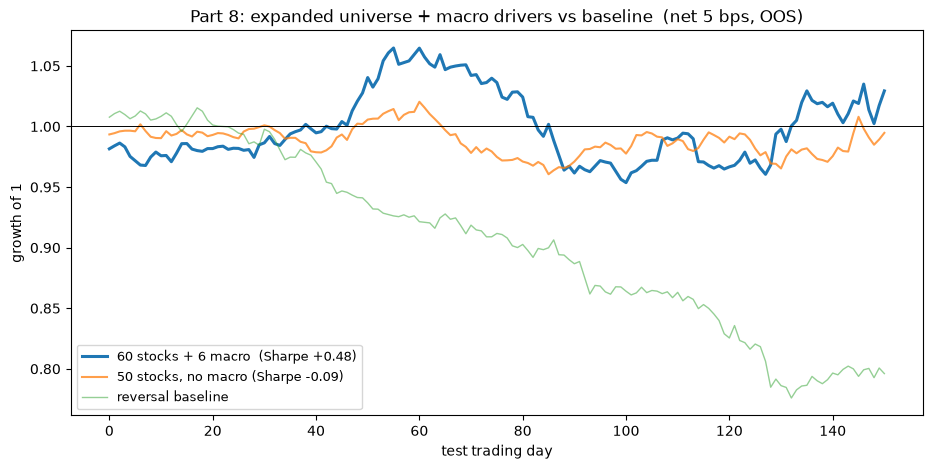

In [12]:
# --- Part 8b: bagged-PCMCI+ on combined data, stable links, validation-tuned test ---

# ── 1. Bagged-PCMCI+ (stocks + macro together) ───────────────────────────────
# B=4 keeps majority-vote (need >=3/4=75%) and runs in ~25 min on 66 variables.
# pc_alpha=0.01 prunes more aggressively → sparser graph per run, faster PC1 step.
B8, block8, PC_ALPHA8 = 4, 20, 0.01
STAB8 = 0.75    # strict: >=3/4 runs must agree (replaces the 50% threshold below)
rng8 = np.random.default_rng(2)
counts8 = np.zeros((N8, N8, tau_max_bt + 1))
base8 = X8[:i_tr8]
print(f'running {B8} bootstrapped PCMCI+ runs on {N8} variables x {i_tr8} days '
      f'(pc_alpha={PC_ALPHA8}, stability>={STAB8:.0%})...')
for bnum in range(B8):
    bs8 = base8[block_bootstrap(len(base8), block8, rng8)]
    g8 = PCMCI(dataframe=pp.DataFrame(bs8, var_names=ALL_NAMES),
               cond_ind_test=ParCorr(significance='analytic'), verbosity=0
               ).run_pcmciplus(tau_min=0, tau_max=tau_max_bt, pc_alpha=PC_ALPHA8)['graph']
    for i in range(N8):
        for j in range(N8):
            for tau in range(1, tau_max_bt + 1):
                if g8[i, j, tau] == '-->' and i != j:
                    counts8[i, j, tau] += 1
    print(f'  run {bnum+1}/{B8} done')

freq8 = counts8 / B8
# Build predictors ONLY for stocks (j < N_s); causes can be any variable (stock OR macro)
stable8 = {
    j: [(i, tau) for i in range(N8) for tau in range(1, tau_max_bt + 1)
        if freq8[i, j, tau] >= STAB8]
    for j in range(N_s)
}
n_stable8   = sum(len(v) for v in stable8.values())
macro_links8 = sum(1 for v in stable8.values() for (i, tau) in v if i >= N_s)
n_predictable = sum(1 for v in stable8.values() if v)
print(f'\nstable links (freq>={STAB8}): {n_stable8} total   '
      f'({macro_links8} macro→stock, {n_stable8-macro_links8} stock→stock)  '
      f'across {n_predictable}/{N_s} stocks')

# ── 2. Show which macro variables lead which stocks ───────────────────────────
print('\n── Macro → Stock causal leads (stable in ≥50% bootstraps) ─────')
for m_idx, m_name in enumerate(lr_mac.columns):
    gi = N_s + m_idx
    hits = [(all_stock_names[j], tau, freq8[gi, j, tau])
            for j in range(N_s) for tau in range(1, tau_max_bt + 1)
            if freq8[gi, j, tau] >= STAB8]
    if hits:
        top = sorted(hits, key=lambda x: -x[2])[:8]
        print(f'  {m_name:>7} → ' + ', '.join(f'{s}@τ{t}({f:.0%})' for s, t, f in top))

# ── 3. Ridge predictor on X8 (features = lagged stable parents from X8) ──────
def ridge_pred8(X, stock_targets, stable, fit_end, lam, tau_max=2):
    """Ridge regression: for each stock j, predict its idiosyncratic return
    using its stable lagged parents from X (which includes both stocks and macro)."""
    Tn = X.shape[0]
    Ns = len(stable)
    P = np.full((Tn, Ns), np.nan)
    rows = np.arange(tau_max, Tn)
    for j in range(Ns):
        Lj = stable[j]
        if not Lj:
            continue
        Xd = np.column_stack([np.ones(len(rows))] + [X[rows - t, i] for (i, t) in Lj])
        y  = stock_targets[rows, j]      # idiosyncratic stock j return
        tr = rows < fit_end
        A, yt = Xd[tr], y[tr]
        reg = lam * np.eye(A.shape[1]); reg[0, 0] = 0.0
        b = np.linalg.solve(A.T @ A + reg, A.T @ yt)
        P[rows, j] = Xd @ b
    return P

vol8 = trailing_vol(R8s, 20)

# ── 4. Choose (lambda, hold, band) on VALIDATION slice ───────────────────────
best8 = None
for lam8 in [1.0, 5.0, 20.0]:
    P8 = ridge_pred8(X8, resid8, stable8, i_tr8, lam8)
    for hold8 in [5, 10, 20]:
        sig8 = smooth(P8, hold8)
        for band8 in [0.0, 0.01, 0.02]:
            rv8, _ = backtest_iv(sig8, R8s, vol8, i_tr8, i_val8, band=band8, cost_bps=5.0)
            shv8 = stats(rv8)[0]
            if best8 is None or shv8 > best8[0]:
                best8 = (shv8, lam8, hold8, band8)

val_sh8, lam8, hold8, band8 = best8
print(f'\nvalidation pick -> lambda={lam8}, hold={hold8}d, band={band8}  '
      f'(val Sharpe@5bps = {val_sh8:.2f})')

# ── 5. Evaluate ONCE on the untouched TEST slice ─────────────────────────────
sig8_final = smooth(ridge_pred8(X8, resid8, stable8, i_tr8, lam8), hold8)
r8t, tn8t  = backtest_iv(sig8_final, R8s, vol8, i_val8, T8, band=band8, cost_bps=5.0)
sh8, hit8, tot8 = stats(r8t)

# Compare with Part 7 result (same test window length, different data)
r7t_cmp, _ = backtest_iv(sig, R, vol, i_val, T, band=band, cost_bps=5.0)
sh7_cmp = stats(r7t_cmp)[0]

rev8 = np.full_like(R8s, np.nan); rev8[1:] = -R8s[:-1]
r_rev8, _ = backtest_iv(rev8, R8s, vol8, i_val8, T8, band=band8, cost_bps=5.0)

print('\n════ HELD-OUT TEST RESULTS (net of 5 bps, validation-chosen params) ════')
print(f'{"Part 7: 50 stocks, no macro":<36}Sharpe = {sh7_cmp:>+5.2f}')
print(f'{"Part 8: 60 stocks + 6 macro":<36}Sharpe = {sh8:>+5.2f}  '
      f'hit={hit8*100:.1f}%  totRet={tot8*100:.2f}%  avgTurn={tn8t.mean():.2f}')
print(f'{"Reversal baseline":<36}Sharpe = {stats(r_rev8)[0]:>+5.2f}')

plt.figure(figsize=(11, 5))
plt.plot(np.cumprod(1 + r8t),    lw=2.2, label=f'60 stocks + 6 macro  (Sharpe {sh8:+.2f})')
plt.plot(np.cumprod(1 + r7t_cmp),lw=1.5, alpha=0.75, label=f'50 stocks, no macro (Sharpe {sh7_cmp:+.2f})')
plt.plot(np.cumprod(1 + r_rev8), lw=1,   alpha=0.5,  label='reversal baseline')
plt.axhline(1.0, color='k', lw=0.7)
plt.title('Part 8: expanded universe + macro drivers vs baseline  (net 5 bps, OOS)')
plt.xlabel('test trading day'); plt.ylabel('growth of 1'); plt.legend(fontsize=9)
plt.show()